## Assignment: Image recognition
- Alumno 1: Alex Ferroni
- Alumno 2: Vittorio Alberto Gianfrate
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
!pip install rasterio

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-03-10 10:03:13.183291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773136993.383556      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773136993.442009      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773136993.878782      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773136993.878829      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773136993.878831      55 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [4]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

In [5]:
import warnings
import rasterio
import numpy as np
import os
import cv2

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    base_path = '/kaggle/input/datasets/alexferroni/recognition/xview_recognition/'
    
    src_raster = rasterio.open(base_path + filename, 'r')
    # --------------------

    # RasterIO to OpenCV
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
   
    return img

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [6]:
import json
import os


json_file = '/kaggle/input/datasets/alexferroni/recognition/xview_recognition/xview_ann_train.json'

print(f"Caricamento annotazioni da: {json_file}")

with open(json_file) as ifs:
    json_data = json.load(ifs)
    
print("Annotazioni caricate con successo!")

Caricamento annotazioni da: /kaggle/input/datasets/alexferroni/recognition/xview_recognition/xview_ann_train.json
Annotazioni caricate con successo!


In [7]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [8]:
from sklearn.model_selection import train_test_split
labels_list = [x.objects[0].category for x in anns]
anns_train, anns_valid = train_test_split(anns, test_size=0.2, random_state=1, shuffle=True,stratify=labels_list)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 14996
Number of validation images: 3750


In [9]:
train_mean = [69.41887293,56.97948485,49.47711569]
train_std = [51.61769765,44.6239849 ,40.89414141]



In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input
# Load architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization, ELU,RandomFlip,Resizing,RandomRotation,RandomFlip,RandomContrast,RandomBrightness
from tensorflow.keras.regularizers import L2
from tensorflow.keras.initializers import HeNormal, Zeros
from tensorflow.keras.optimizers import Nadam
# Carichiamo il modello ResNet50 senza i suoi layer densi finali (include_top=False)
# e con i pesi già addestrati su ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# Congela tutti i layer convoluzionali
base_model.trainable = False

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Definisci l'input
inputs = Input(shape=(224, 224, 3))

# 1. Data Augmentation (che avevi già)
x = RandomFlip("horizontal_and_vertical")(inputs)


# 2. Passa le immagini alla ResNet50 (mettendo training=False per i layer di BatchNormalization interni)
x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

# 4. Output a 13 classi
x = Dropout(0.3)(x) 
outputs = Dense(13, activation='softmax')(x)

# Crea il modello finale
model = Model(inputs, outputs)

model.summary()

I0000 00:00:1773137018.315052      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 13)             │        26,637 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,614,349 (90.08 MB)

 Trainable params: 26,637 (104.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
from sklearn.utils import class_weight
import numpy as np

train_labels = [ann.objects[0].category for ann in anns_train]
unique_classes = np.unique(train_labels)

weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_labels
)

name_to_id = {v: k for k, v in categories.items()}

alpha_array = np.ones(len(categories), dtype=np.float32)

for class_name, weight in zip(unique_classes, weights_values):
    if class_name in name_to_id:
        class_id = name_to_id[class_name]
        alpha_array[class_id] = weight
        print(f"Classe: {class_name:<20} ID: {class_id:<3} Peso: {weight:.4f}")

alpha_list = alpha_array.tolist()

print("\nLISTA DEFINITIVA PRONTA PER FOCAL LOSS:", alpha_list)

Classe: Building             ID: 8   Peso: 0.4012
Classe: Bus                  ID: 2   Peso: 0.8158
Classe: Cargo plane          ID: 0   Peso: 2.2707
Classe: Dump truck           ID: 6   Peso: 1.1664
Classe: Excavator            ID: 7   Peso: 1.8281
Classe: Fishing vessel       ID: 5   Peso: 2.0417
Classe: Helipad              ID: 9   Peso: 12.9611
Classe: Motorboat            ID: 4   Peso: 1.3492
Classe: Pylon                ID: 12  Peso: 4.6142
Classe: Shipping container   ID: 11  Peso: 0.9471
Classe: Small car            ID: 1   Peso: 0.4338
Classe: Storage tank         ID: 10  Peso: 0.9817
Classe: Truck                ID: 3   Peso: 0.6525

LISTA DEFINITIVA PRONTA PER FOCAL LOSS: [2.270745038986206, 0.43382418155670166, 0.8157980442047119, 0.6524538993835449, 1.349167823791504, 2.041661024093628, 1.1663684844970703, 1.8281116485595703, 0.4012307822704315, 12.961106300354004, 0.9817348718643188, 0.9470759034156799, 4.614153861999512]


In [12]:
from tensorflow.keras.optimizers import Adam

# Learning rate is changed to 0.001
opt = Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
model.compile(optimizer=opt, loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=alpha_list), metrics=['accuracy'])

In [13]:
from tensorflow.keras.applications.resnet50 import preprocess_input

def generator_images(objs, batch_size, do_shuffle=False, mean=None, std=None):
    while True:
        if do_shuffle:
            np.random.shuffle(objs)
        groups = [objs[i:i+batch_size] for i in range(0, len(objs), batch_size)]
        for group in groups:
            images, labels = [], []
            for (filename, obj) in group:
                
                img = load_geoimage(filename)
                
                
                # ---> IL SEGRETO È QUI: via la vecchia normalizzazione <---
                img = preprocess_input(img.astype(np.float32))
               
                
                images.append(img)
                probabilities = np.zeros(len(categories))
                probabilities[list(categories.values()).index(obj.category)] = 1
                labels.append(probabilities)
            images = np.array(images).astype(np.float32)
            labels = np.array(labels).astype(np.float32)
            yield images, labels

In [14]:
def mixup_generator(objs, batch_size, alpha=0.3, mean=None, std=None):
    while True:
        # Prendi due batch casuali
        idx1 = np.random.choice(len(objs), batch_size)
        idx2 = np.random.choice(len(objs), batch_size)
        
        images1, labels1 = [], []
        images2, labels2 = [], []
        
        for i, j in zip(idx1, idx2):
            filename1, obj1 = objs[i]
            filename2, obj2 = objs[j]
            
            img1 = load_geoimage(filename1)
            img2 = load_geoimage(filename2)
            
            img1 = preprocess_input(img1.astype(np.float32))
            img2 = preprocess_input(img2.astype(np.float32))
            
            lbl1 = np.zeros(len(categories))
            lbl1[list(categories.values()).index(obj1.category)] = 1
            lbl2 = np.zeros(len(categories))
            lbl2[list(categories.values()).index(obj2.category)] = 1
            
            images1.append(img1)
            labels1.append(lbl1)
            images2.append(img2)
            labels2.append(lbl2)
        
        images1 = np.array(images1, dtype=np.float32)
        images2 = np.array(images2, dtype=np.float32)
        labels1 = np.array(labels1, dtype=np.float32)
        labels2 = np.array(labels2, dtype=np.float32)
        
        # MixUp
        lam = np.random.beta(alpha, alpha)
        images = lam * images1 + (1 - lam) * images2
        labels = lam * labels1 + (1 - lam) * labels2
        
        yield images, labels




In [15]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('resnet_phase1.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1,min_lr=1e-7)
early_stop = EarlyStopping('val_accuracy', patience=22, verbose=1)
terminate = TerminateOnNaN()
callbacks_phase1 = [model_checkpoint, reduce_lr, early_stop, terminate]

In [16]:
# Generate the list of objects from annotations
objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]
# Generators
batch_size = 32
# Usa questo al posto del train_generator
train_generator = mixup_generator(objs_train, batch_size,
                                   alpha=0.3)
# in caso da rimettere il vecchioo
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False)

In [17]:
import math
import numpy as np

print('Training model PHASE 1')
epochs = 20
train_steps = math.ceil(len(objs_train)/batch_size)
valid_steps = math.ceil(len(objs_valid)/batch_size)
h_phase1 = model.fit(train_generator, steps_per_epoch=train_steps, validation_data=valid_generator, validation_steps=valid_steps, epochs=epochs, callbacks=callbacks_phase1, verbose=1)
# Best validation model
best_idx = int(np.argmax(h_phase1.history['val_accuracy']))
best_value = np.max(h_phase1.history['val_accuracy'])
print('Best validation model: epoch ' + str(best_idx+1), ' - val_accuracy ' + str(best_value))

Training model PHASE 1
Epoch 1/20


I0000 00:00:1773137039.498055     128 service.cc:152] XLA service 0x7b8670013970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773137039.498094     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773137041.406232     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/469 ━━━━━━━━━━━━━━━━━━━━ 1:44:35 13s/step - accuracy: 0.1250 - loss: 2.5873

I0000 00:00:1773137046.276666     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4280 - loss: 1.4586
Epoch 1: val_accuracy improved from -inf to 0.66000, saving model to resnet_phase1.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 704s 1s/step - accuracy: 0.4282 - loss: 1.4581 - val_accuracy: 0.6600 - val_loss: 0.6299 - learning_rate: 0.0010
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.5577 - loss: 1.0465
Epoch 2: val_accuracy improved from 0.66000 to 0.67040, saving model to resnet_phase1.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 422ms/step - accuracy: 0.5577 - loss: 1.0464 - val_accuracy: 0.6704 - val_loss: 0.5973 - learning_rate: 0.0010
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.5849 - loss: 0.9317
Epoch 3: val_accuracy did not improve from 0.67040
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 305ms/step - accuracy: 0.5849 - loss: 0.9317 - val_accuracy: 0.6507 - val_loss: 0.5717 - learning_rate: 0.0010
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.5973 - loss: 0.891

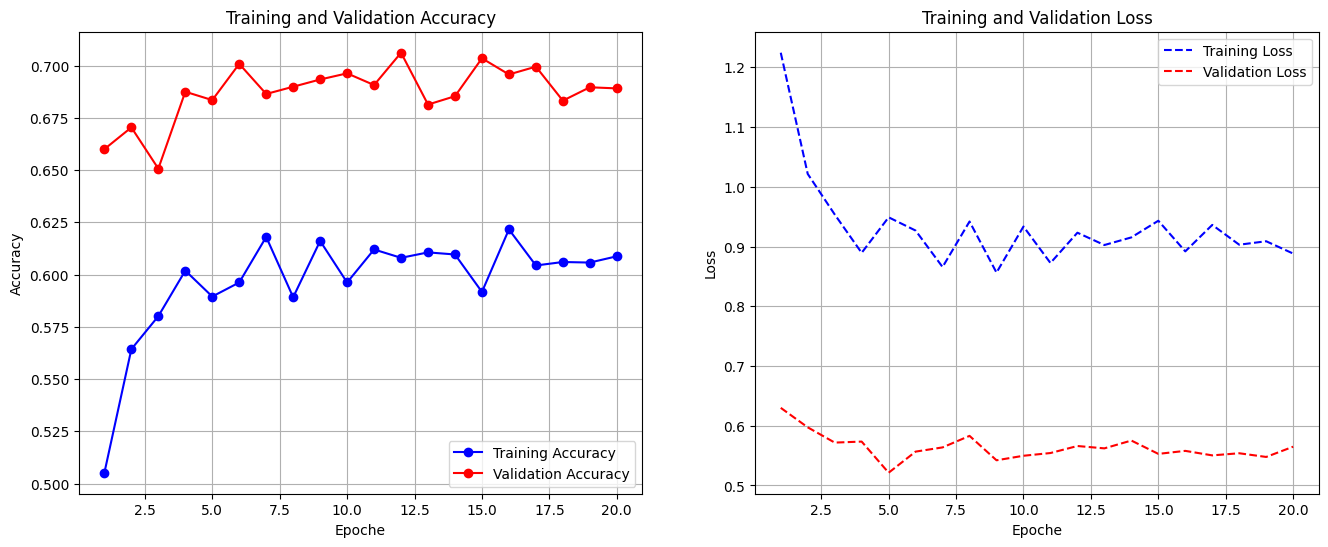

In [18]:
import matplotlib.pyplot as plt

def plot_results(history):
    
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 6))

    # --- GRAFICO 1: ACCURACY
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoche')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # --- GRAFICO 2: LOSS 
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue', linestyle='--')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoche')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.show()


plot_results(h_phase1)

In [19]:
# PHASE 2
model.load_weights('resnet_phase1.keras')
#SBLOCCA LA RESNET
base_model.trainable = True

for layer in base_model.layers:
    if layer.name.startswith('conv5'):
        layer.trainable = True
    else:
        layer.trainable = False
        
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
opt = Adam(learning_rate=1e-5, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
model.compile(optimizer=opt, loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=alpha_list), metrics=['accuracy'])
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1,min_lr=1e-7)
early_stop = EarlyStopping('val_accuracy', patience=22, verbose=1)
terminate = TerminateOnNaN()
callbacks_phase2 = [model_checkpoint, reduce_lr, early_stop, terminate]
epochs =50

h_phase2 = model.fit(train_generator, steps_per_epoch=train_steps, validation_data=valid_generator, validation_steps=valid_steps, epochs=epochs, callbacks=callbacks_phase2, verbose=1)
# Best validation model
best_idx = int(np.argmax(h_phase2.history['val_accuracy']))
best_value = np.max(h_phase2.history['val_accuracy'])
print('Best validation model: epoch ' + str(best_idx+1), ' - val_accuracy ' + str(best_value))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.6292 - loss: 0.8371
Epoch 1: val_accuracy improved from -inf to 0.72000, saving model to model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 162s 311ms/step - accuracy: 0.6292 - loss: 0.8370 - val_accuracy: 0.7200 - val_loss: 0.5098 - learning_rate: 1.0000e-05
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.6570 - loss: 0.7799
Epoch 2: val_accuracy improved from 0.72000 to 0.73093, saving model to model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 162s 347ms/step - accuracy: 0.6570 - loss: 0.7798 - val_accuracy: 0.7309 - val_loss: 0.4755 - learning_rate: 1.0000e-05
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6850 - loss: 0.7385
Epoch 3: val_accuracy improved from 0.73093 to 0.73120, saving model to model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 307ms/step - accuracy: 0.6850 - loss: 0.7385 - val_accuracy: 0.7312 - val_loss: 0.4717 - learning_rate: 1.0000e-05
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 

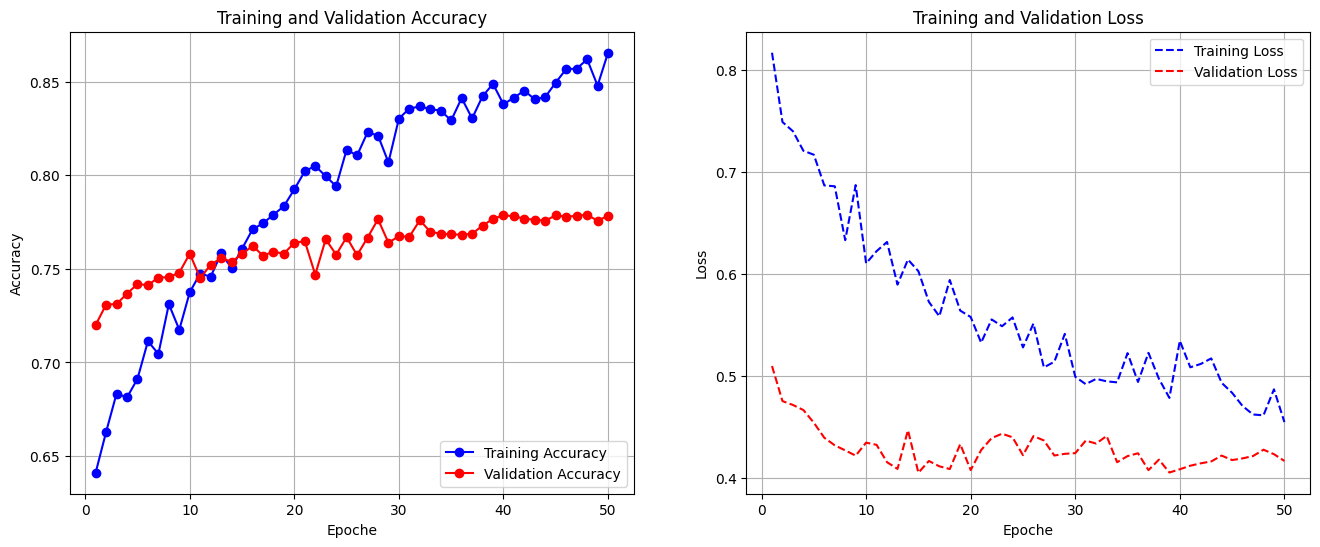

In [20]:
plot_results(h_phase2)

#### Validation
Compute validation metrics.

In [21]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

In [22]:
import numpy as np

model.load_weights('model.keras')
y_true, y_pred = [], []
for ann in anns_valid:
    # Load image
    image = load_geoimage(ann.filename)
    image = preprocess_input(image.astype(np.float32))  
            
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        y_true.append(obj_pred.category)
        y_pred.append(pred_category)

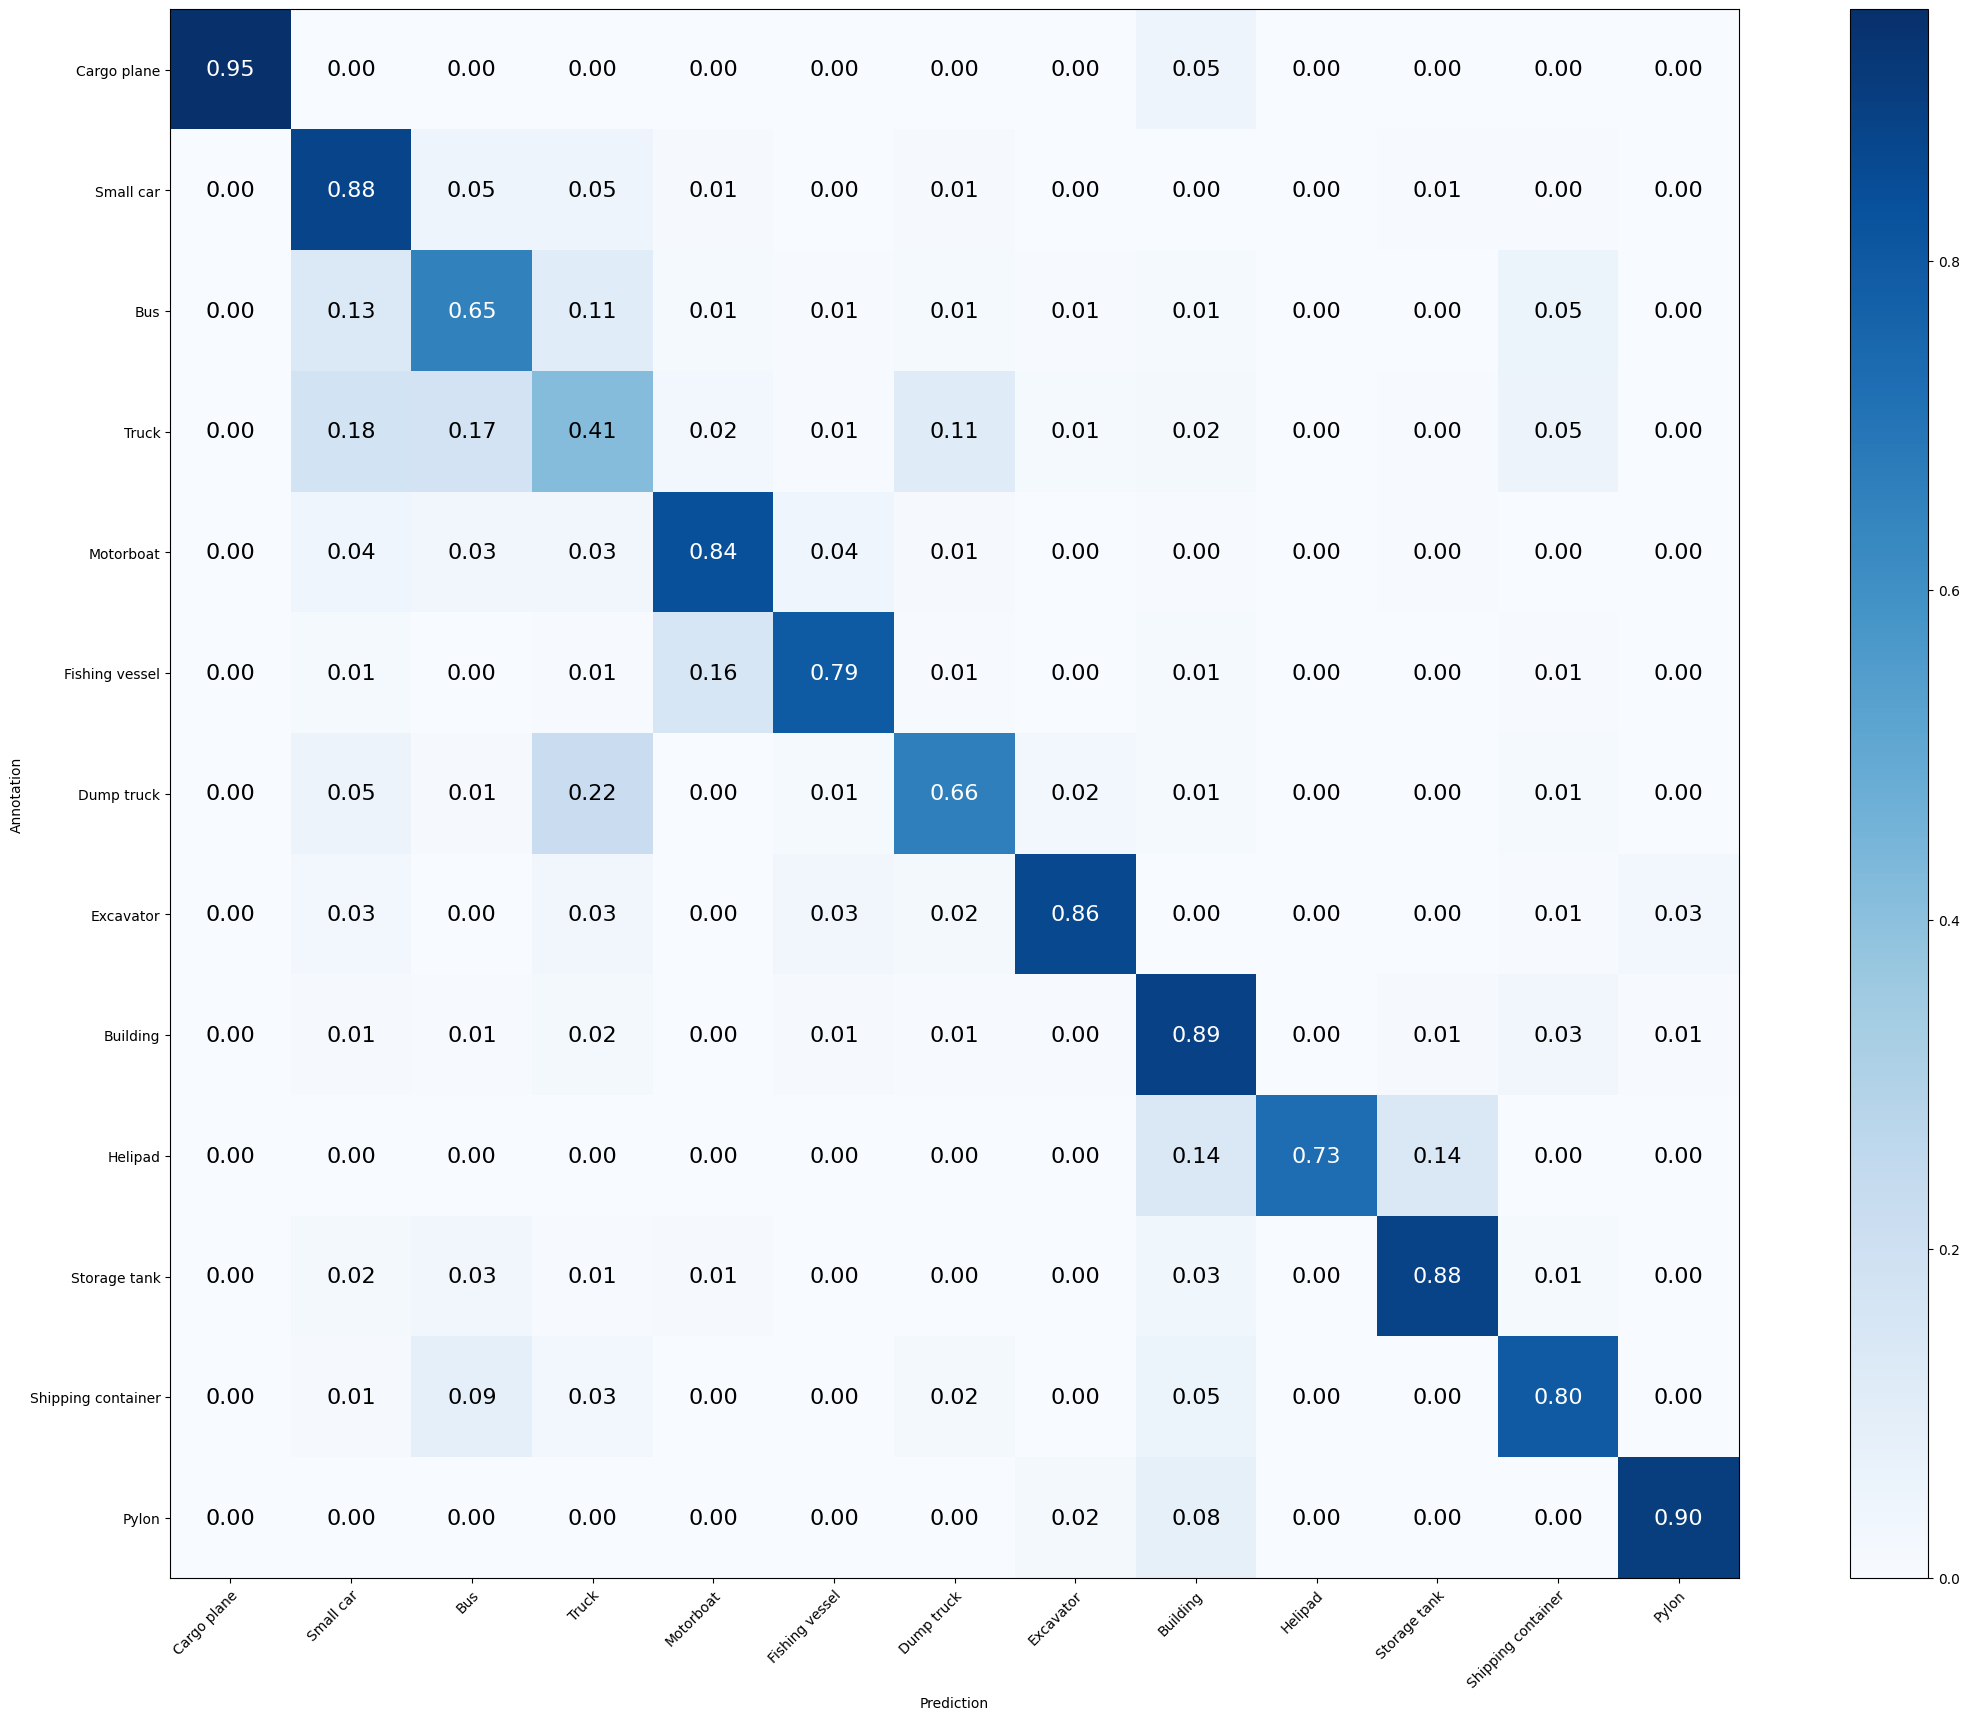

In [23]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories)

In [24]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 77.893%
Mean Recall: 78.817%
Mean Precision: 80.480%
> Cargo plane: Recall: 95.276% Precision: 98.374% Specificity: 99.945% Dice: 96.800%
> Small car: Recall: 87.669% Precision: 77.733% Specificity: 94.587% Dice: 82.403%
> Bus: Recall: 65.254% Precision: 59.536% Specificity: 95.377% Dice: 62.264%
> Truck: Recall: 41.403% Precision: 53.043% Specificity: 95.103% Dice: 46.506%
> Motorboat: Recall: 83.645% Precision: 78.855% Specificity: 98.643% Dice: 81.179%
> Fishing vessel: Recall: 79.433% Precision: 78.873% Specificity: 99.169% Dice: 79.152%
> Dump truck: Recall: 65.992% Precision: 68.487% Specificity: 97.859% Dice: 67.216%
> Excavator: Recall: 86.076% Precision: 87.742% Specificity: 99.471% Dice: 86.901%
> Building: Recall: 88.734% Precision: 91.404% Specificity: 98.020% Dice: 90.049%
> Helipad: Recall: 72.727% Precision: 100.000% Specificity: 100.000% Dice: 84.211%
> Storage tank: Recall: 88.095% Precision: 92.832% Specificity: 99.421% Dice: 90.401%
> Shipping containe

#### Testing
Try to improve the results provided in the competition.

In [25]:
import os
import numpy as np

anns = []
for (dirpath, dirnames, filenames) in os.walk('/kaggle/input/datasets/alexferroni/recognition/xview_recognition/xview_test'):
    for filename in filenames:
        relative_path = os.path.join('xview_test', filename)
        image = GenericImage(relative_path)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [26]:
import numpy as np

model.load_weights('model.keras')
predictions_data = {"images": {}, "annotations": {}}
for idx, ann in enumerate(anns):
    image_data = {"image_id": ann.filename.split('/')[-1], "filename": ann.filename, "width": int(ann.tile[2]), "height": int(ann.tile[3])}
    predictions_data["images"][idx] = image_data
    # Load image
    image = load_geoimage(ann.filename)
    image = preprocess_input(image.astype(np.float32)) 
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        annotation_data = {"image_id": ann.filename.split('/')[-1], "category_id": pred_category, "bbox": [int(x) for x in obj_pred.bb]}
        predictions_data["annotations"][idx] = annotation_data

In [27]:
with open("prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)